# Finding multiple minima — the restart family

The **restart** methods leave the objective untouched and instead choose
*where to start* each local solve cleverly.

| method | how it starts | reference |
|---|---|---|
| `multistart` | random / Sobol sampling of the box | classic |
| `mlsl` | Multi-Level Single Linkage clustering: start only from well-separated, promising samples | Rinnooy Kan & Timmer, *Math. Program.* **39** (1987) |

The point of MLSL is to **avoid descending the same basin twice**. See
`docs/src/find-minima.md` for details and references.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pounce
print("pounce", pounce.__version__)

pounce 0.7.0


## The test landscape

Rastrigin has a regular lattice of minima inside the box, with the global one at the origin.

/var/folders/gq/k1kgbl7n539_4dl1md8x3jt80000gn/T/ipykernel_49990/2872884343.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


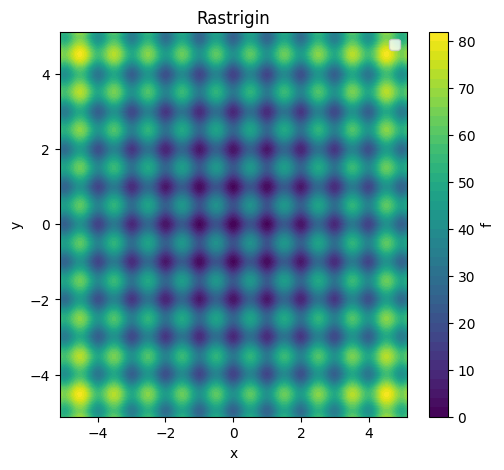

In [2]:
# Rastrigin: a lattice of local minima; single global minimum at the origin.
def fun(z):
    return 10*len(z) + sum(zi*zi - 10*np.cos(2*np.pi*zi) for zi in z)

def jac(z):
    return np.array([2*zi + 20*np.pi*np.sin(2*np.pi*zi) for zi in z])

def hess(z):
    return np.diag([2 + 40*np.pi**2*np.cos(2*np.pi*zi) for zi in z])

bounds = [(-5.12, 5.12)] * 2

def plot_landscape(minima=None, title="", chain=None):
    xs = np.linspace(-5.12, 5.12, 400)
    X, Y = np.meshgrid(xs, xs)
    Z = 20 + (X**2 - 10*np.cos(2*np.pi*X)) + (Y**2 - 10*np.cos(2*np.pi*Y))
    plt.figure(figsize=(5.6, 5))
    plt.contourf(X, Y, Z, levels=40, cmap="viridis"); plt.colorbar(label="f")
    if chain is not None and len(chain):
        C = np.array(chain)
        plt.plot(C[:, 0], C[:, 1], "-o", c="white", ms=4, lw=1, alpha=0.7,
                 label="hop chain")
    if minima is not None and len(minima):
        M = np.array(minima)
        plt.scatter(M[:, 0], M[:, 1], c="red", s=70, edgecolors="white",
                    zorder=5, label=f"{len(M)} minima")
    plt.legend(loc="upper right")
    plt.title(title); plt.xlabel("x"); plt.ylabel("y"); plt.show()

plot_landscape(title="Rastrigin")

## Multistart

Plain random restarts. Simple, embarrassingly parallel, and a strong baseline.

  f=  0.00000  at (+0.0000, +0.0000)
  f=  3.97983  at (+1.9899, +0.0000)
  f=  4.97479  at (-0.9950, -1.9899)
  f= 16.91420  at (-3.9798, +0.9950)
  f= 16.91420  at (+0.9950, +3.9798)
  f= 16.91420  at (-0.9950, +3.9798)
  f= 19.89907  at (+1.9899, -3.9798)
  f= 25.86868  at (+4.9747, -0.9950)

status=target_reached  found=8  solves=8


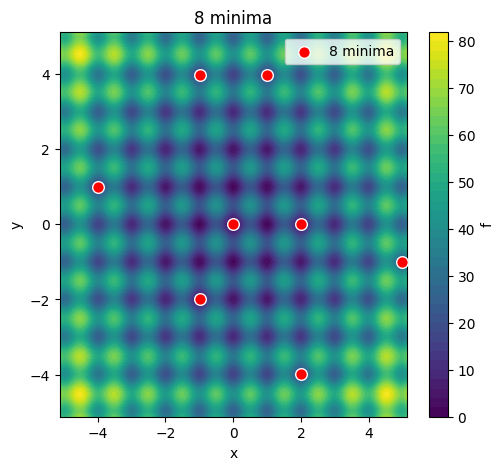

In [3]:
r = pounce.find_minima(fun, [0.3, 0.3], method="multistart", jac=jac, hess=hess,
                   bounds=bounds, n_minima=8, max_solves=200, patience=60,
                   dedup=1e-2, seed=1, options={"print_level": 0, "tol": 1e-9})
for x, f in zip(r.minima, r.values):
    print(f"  f={f:9.5f}  at ({x[0]:+.4f}, {x[1]:+.4f})")
print(f"\nstatus={r.status}  found={len(r)}  solves={r.n_solves}")
plot_landscape(r.minima, title=f"{len(r)} minima")

## MLSL

MLSL clusters its sample pool and starts a local solve only from a sample that has no *better* neighbor nearby and is not close to an already-found minimum.

  f=  0.00000  at (+0.0000, +0.0000)
  f=  1.98992  at (-0.9950, -0.9950)

status=budget_exhausted  found=2  solves=2


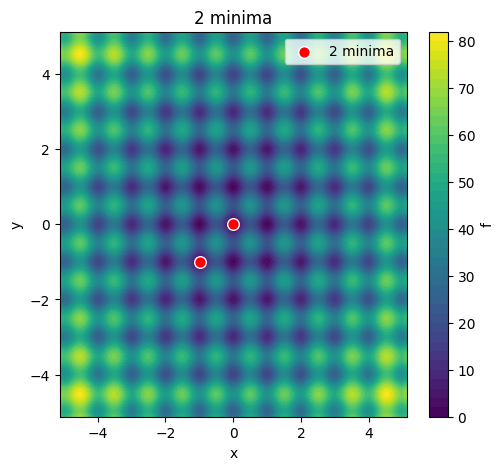

In [4]:
r = pounce.find_minima(fun, [0.3, 0.3], method="mlsl", jac=jac, hess=hess,
                   bounds=bounds, n_minima=8, max_solves=200, patience=60,
                   dedup=1e-2, seed=1, options={"print_level": 0, "tol": 1e-9})
for x, f in zip(r.minima, r.values):
    print(f"  f={f:9.5f}  at ({x[0]:+.4f}, {x[1]:+.4f})")
print(f"\nstatus={r.status}  found={len(r)}  solves={r.n_solves}")
plot_landscape(r.minima, title=f"{len(r)} minima")

## Where MLSL pays off: redundant descents

On Rastrigin the basins are well separated, so random starts rarely collide
and multistart is already efficient. On a **funneling** landscape — where
many starts drain into the same basin — multistart wastes solves
re-descending knowns, while MLSL's clustering skips them. The six-hump camel
shows this clearly.

In [5]:
def camel(z):
    x, y = z
    return (4 - 2.1*x**2 + x**4/3)*x**2 + x*y + (-4 + 4*y**2)*y**2
def camel_jac(z):
    x, y = z
    return np.array([(8 - 8.4*x**2 + 2*x**4)*x + y, x + (-8 + 16*y**2)*y])
def camel_hess(z):
    x, y = z
    return np.array([[8 - 25.2*x**2 + 10*x**4, 1.0], [1.0, -8 + 48*y**2]])
cbounds = [(-2.0, 2.0), (-1.5, 1.5)]

print(f"{'method':11s} {'solves':>7} {'redundant':>10}   (to find all 6 camel minima)")
for m in ["multistart", "mlsl"]:
    r = pounce.find_minima(camel, [0.5, 0.5], method=m, jac=camel_jac,
                           hess=camel_hess, bounds=cbounds, n_minima=6,
                           max_solves=300, patience=80, dedup=1e-3, seed=0,
                           options={"print_level": 0, "tol": 1e-9})
    redundant = sum(1 for t in r.trace if not t["accepted"])
    print(f"{m:11s} {r.n_solves:7d} {redundant:10d}")

method       solves  redundant   (to find all 6 camel minima)
multistart       15          9


mlsl              6          0


## Choosing within the restart family

* **`multistart`** — the default baseline; trivially parallel; pair with
  Sobol sampling (`strategy_kw={"sobol": True}`, on by default) for coverage.
* **`mlsl`** — when each local solve is expensive and the landscape funnels,
  so avoiding redundant descents matters.

Restart methods make **no assumption about smoothness of the repulsion** and
need only `bounds` to define the sampling box. See `docs/src/find-minima.md`
for cross-family guidance.